In [1]:
"""
Anneal counterpart of paris5_ext.py (cf. paris4_sc_ext.py vs paris3_sc_ext.py).

Continues from a converged EMRI_G point/covariance (cf.
paper/emri_g/emri_g_stage2_f.ipynb, maxld_pt1 from stage2_f_smol) with a
single seed and an S-annealing schedule on the coherent (pure) f-statistic
log_density, instead of the multi-seed LHS-seeded merge search paris5_ext.py
runs.
"""
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_pure_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12 #NOTE: changed!
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

def icrs_to_ecliptic(qK_icrs, phiK_icrs, eps_deg=23.43929111):
    """
    Convert a sky direction (colatitude, longitude) from the ICRS/equatorial
    frame (qK = pi/2 - dec, phiK = ra) to the ecliptic frame (SSB frame used
    by the LISA response, is_ecliptic_latitude=False convention) via the
    standard equatorial<->ecliptic rotation with J2000 mean obliquity eps.
    """
    dec = np.pi / 2 - qK_icrs
    ra = phiK_icrs
    eps = np.deg2rad(eps_deg)

    sin_beta = np.sin(dec) * np.cos(eps) - np.cos(dec) * np.sin(ra) * np.sin(eps)
    beta = np.arcsin(sin_beta)

    y = np.cos(dec) * np.sin(ra) * np.cos(eps) + np.sin(dec) * np.sin(eps)
    x = np.cos(dec) * np.cos(ra)
    lam = np.arctan2(y, x) % (2 * np.pi)

    qK_ecl = np.pi / 2 - beta
    phiK_ecl = lam
    return qK_ecl, phiK_ecl

# Mojito light EMRI_G (matches paper/emri_g/emri_g_stage2_f.ipynb)
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

print("Setting up log_density and prior functions...")

# S schedule: jump to next S after stuck_iters of no improvement
S_schedule  = [3.0, 10.0, 30.0]
stuck_iters = 10000

# annealing dict
anneal_state = {
    'S':              S_schedule[0],
    'stage':          0,         # index into S_schedule
    'ref_max_ld':     None,      # max_ld at last check
    'ref_iter':       0,
    'stuck_count':    0,
}


def log_density(params):
    """
    Coherent (pure) f-statistic (loglike_pure_noise.LogLike), row-by-row,
    scaled by the current anneal temperature anneal_state['S'].
    """
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cosqS_i)
            theta = [
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
            ]
            out[i] = float(loglike_obj(theta)) #* anneal_state['S']
        except Exception:
            pass
    return out


def prior_transform(u):
    # EMRI_G, matches emri_g_stage2_f.ipynb box
    logm1lim = [5.82507, 5.82762]
    logm2lim = [1.99252, 1.99310]
    alim = [0.49334, 0.50078]
    p0lim = [15.70599, 15.75367]
    e0lim = [0.74388, 0.74418]
    cosqSlim = [0.79926, 0.86149]
    phiSlim = [3.48384, 3.66905]

    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.82507, 5.82762]
    logm2lim = [1.99252, 1.99310]
    alim = [0.49334, 0.50078]
    p0lim = [15.70599, 15.75367]
    e0lim = [0.74388, 0.74418]
    cosqSlim = [0.79926, 0.86149]
    phiSlim = [3.48384, 3.66905]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u


Using dt=5s, T=1.0yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
Setting up log_density and prior functions...


In [2]:
#NOTE:corrected
# qS   = 0.5905743164658463
# phiS = 3.580825804842126
# qK   = 0.9327436243181905
# phiK = 3.6550014190179883

In [3]:
pwd

'/nfs/home/svu/e1498138/emri_search/work'

In [4]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage2_f_anneal/'


In [5]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [6]:
sampler.now_covariances

[array([[ 4.55991035e-03,  4.47604613e-03,  4.54192311e-03,
         -4.55078336e-03, -4.54940111e-03,  6.54408979e-04,
          7.80718176e-04],
        [ 4.47604613e-03,  4.75308428e-03,  4.42175164e-03,
         -4.42045380e-03, -4.62723785e-03,  4.80554329e-04,
          2.28471114e-03],
        [ 4.54192311e-03,  4.42175164e-03,  4.52827593e-03,
         -4.53770343e-03, -4.51446536e-03,  6.64936880e-04,
          6.09302983e-04],
        [-4.55078336e-03, -4.42045380e-03, -4.53770343e-03,
          4.54775296e-03,  4.51921272e-03, -6.72460997e-04,
         -5.78630099e-04],
        [-4.54940111e-03, -4.62723785e-03, -4.51446536e-03,
          4.51921272e-03,  4.61210554e-03, -5.91164076e-04,
         -1.47886095e-03],
        [ 6.54408979e-04,  4.80554329e-04,  6.64936880e-04,
         -6.72460997e-04, -5.91164076e-04,  1.64791099e-03,
         -8.61649205e-05],
        [ 7.80718176e-04,  2.28471114e-03,  6.09302983e-04,
         -5.78630099e-04, -1.47886095e-03, -8.61649205e-05

In [7]:
sampler.config

SamplerConfig(seed=953453411, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [8]:
len(sampler.now_covariances)

1

In [9]:
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 0.8306067129371271,
 3.5808]

In [10]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 5.82741723,  1.99299752,  0.50014982, 15.71071697,  0.74399629,
         0.82943983,  3.56739025]])

In [11]:
log_density(maxld_pt1)

array([100.33997373])

In [12]:
def compX(pt):
    logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = np.asarray(pt).ravel()
    qS_i = np.arccos(cosqS_i)
    h_temp = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS_i, phiS_i, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
        T=T, dt=dt,
    ))
    return float(gwf.Xstat(loglike_obj.signal, h_temp))

In [13]:
compX(maxld_pt1)

100.57487878792692

In [14]:
compX(param_true)

100.56542907746503

In [15]:
log_density([param_true])

array([100.32605701])

In [16]:
param_ranges = [(5.82507, 5.82762),
                (1.99252, 1.99310),
                (0.49334, 0.50078),
                (15.70599, 15.75367),
                (0.74388, 0.74418),
                (0.79926, 0.86149),
                (3.48384, 3.66905)
                ]
param_ranges



[(5.82507, 5.82762),
 (1.99252, 1.9931),
 (0.49334, 0.50078),
 (15.70599, 15.75367),
 (0.74388, 0.74418),
 (0.79926, 0.86149),
 (3.48384, 3.66905)]

In [17]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 0.8306067129371271,
 3.5808]

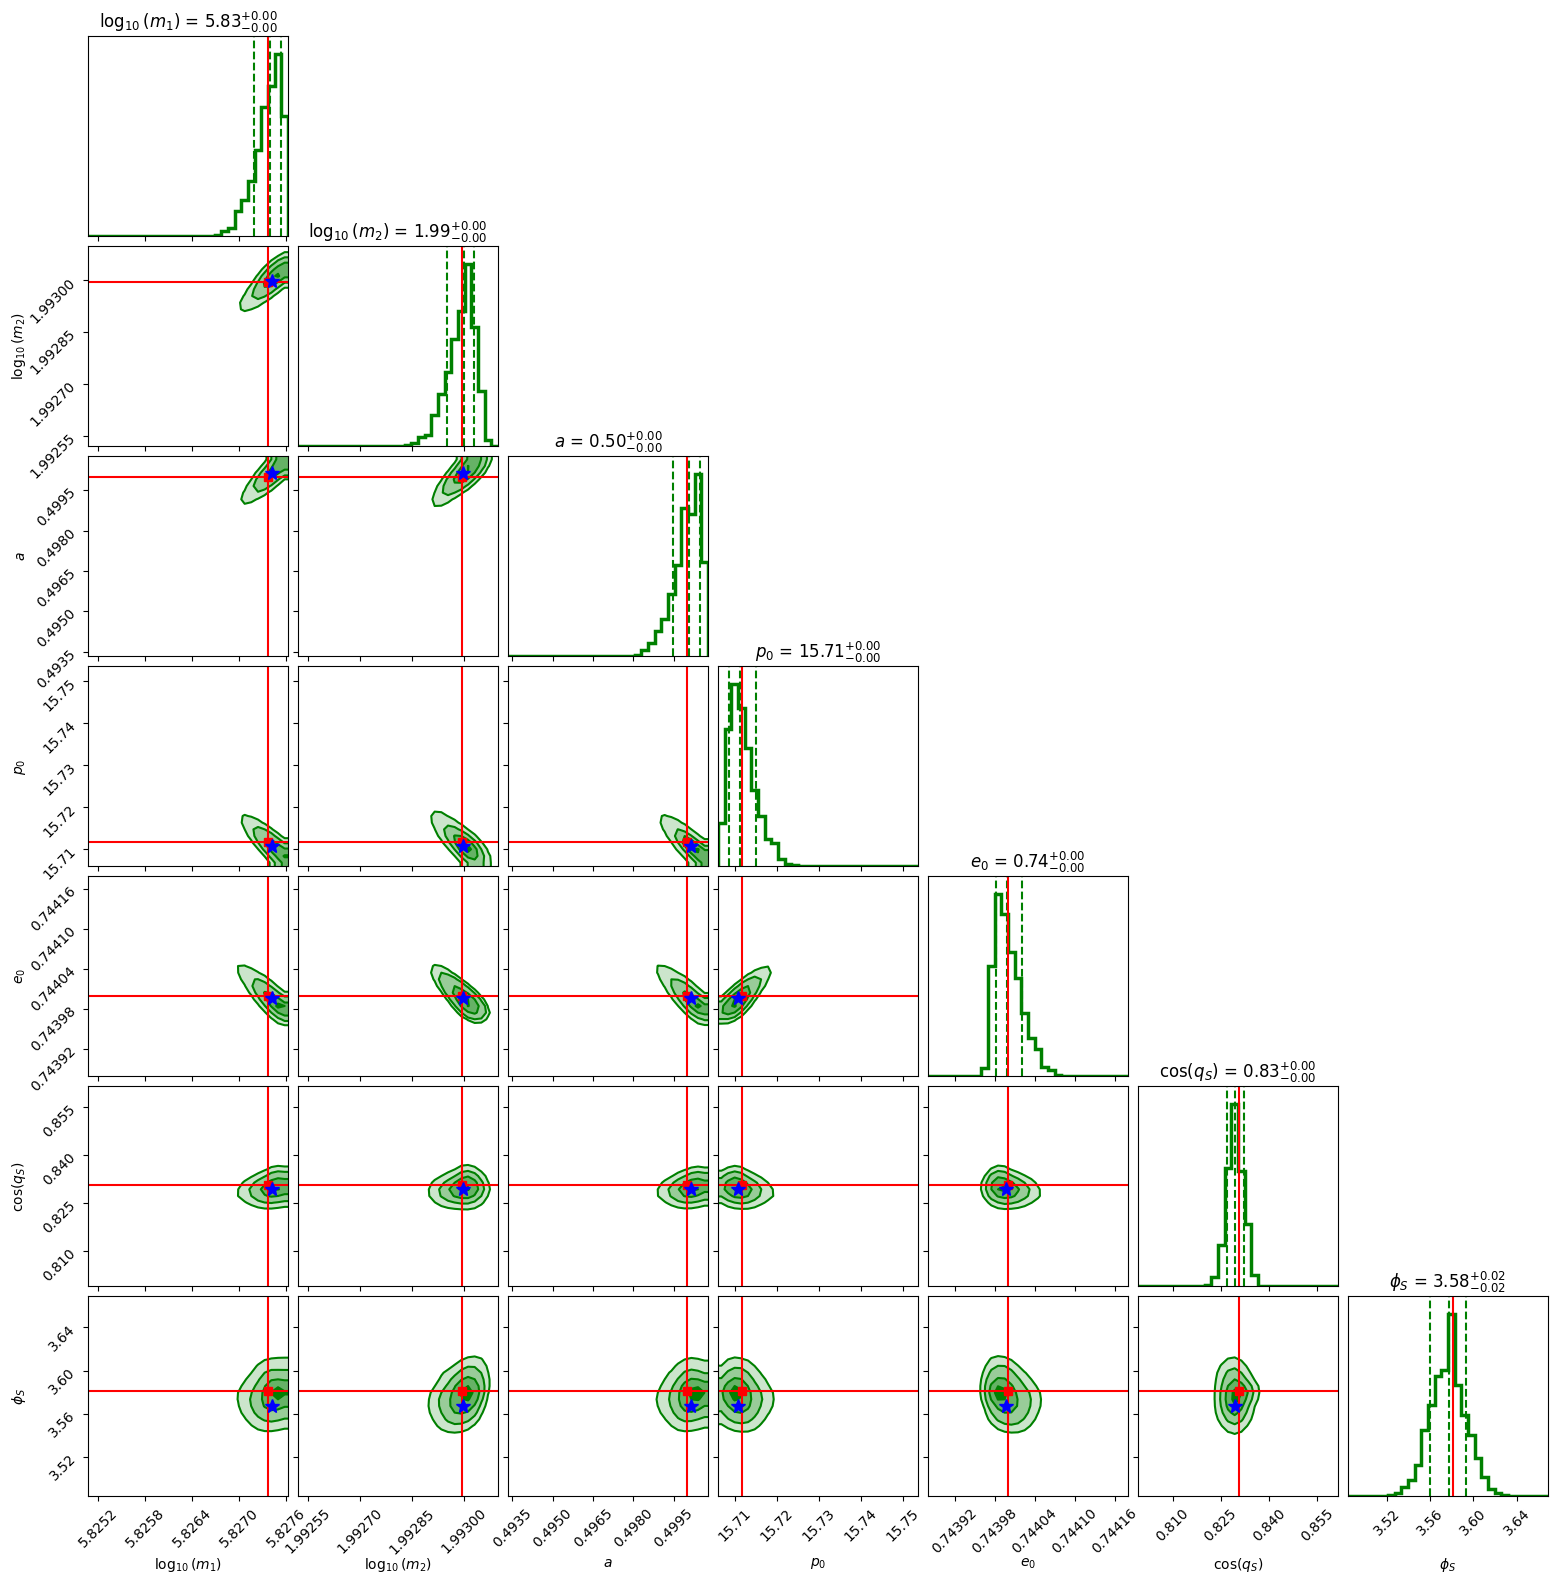

In [18]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




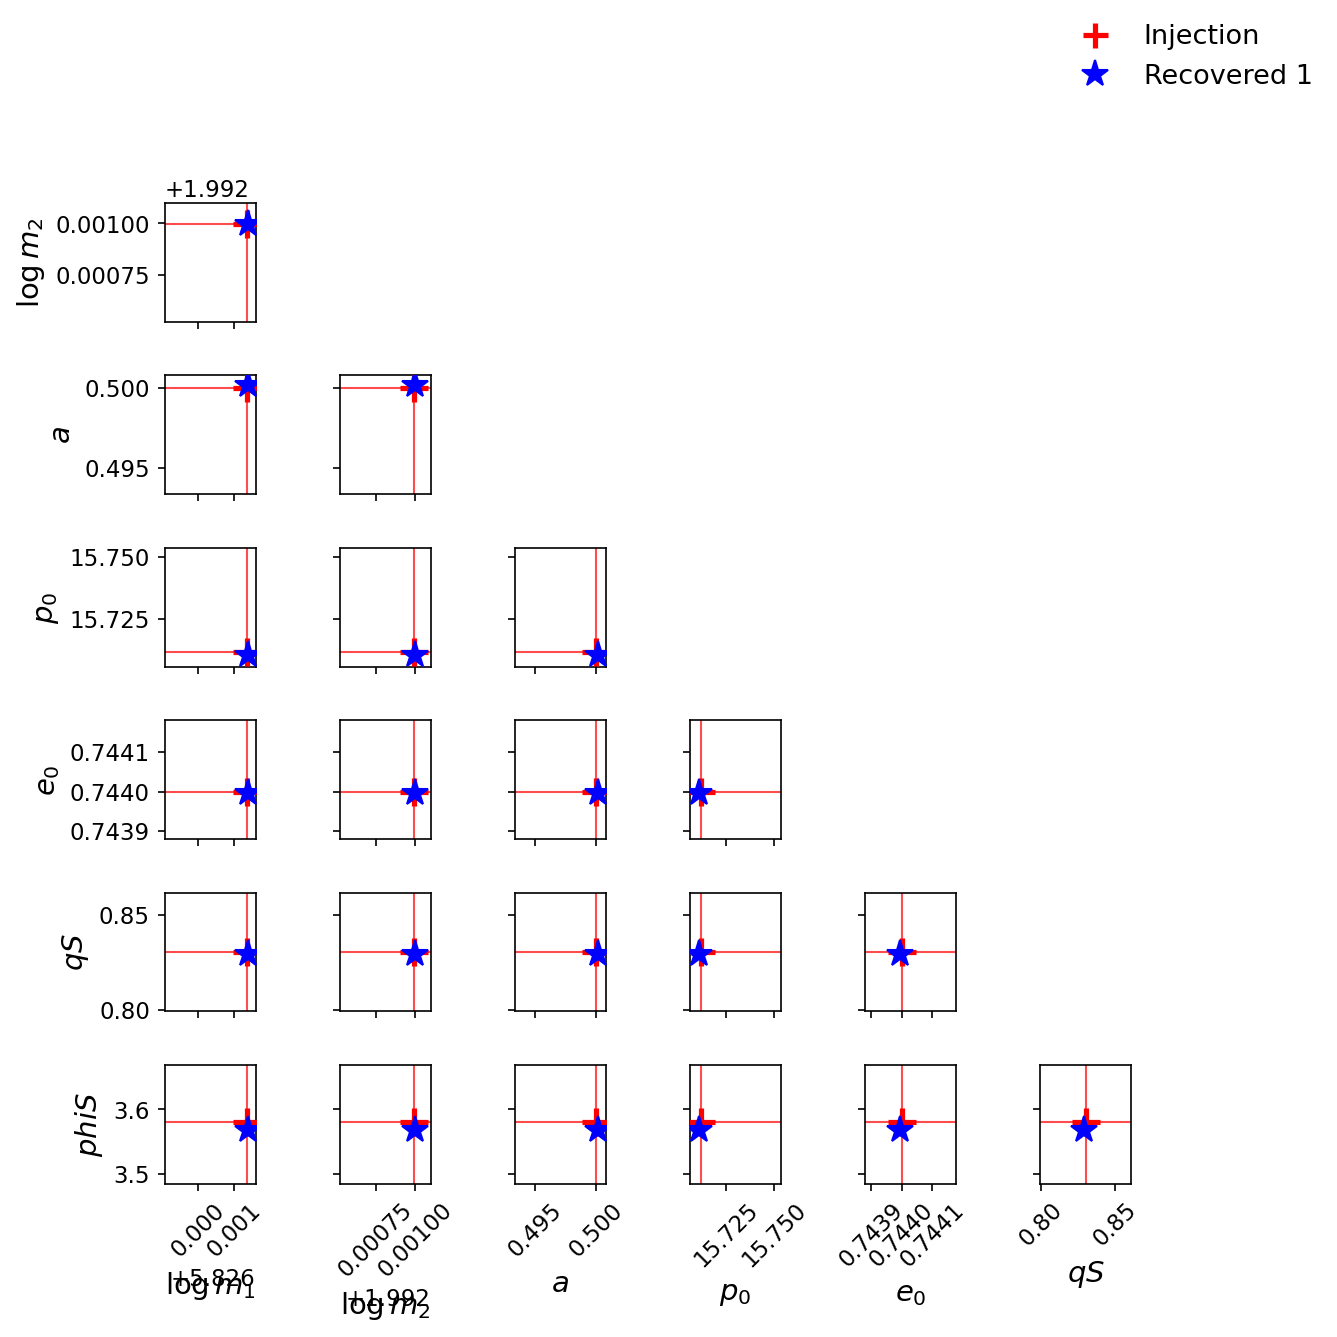

In [19]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()


# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

                
        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered 1'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [20]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.82741723,  1.99299752,  0.50014982, 15.71071697,  0.74399629,
         0.82943983,  3.56739025]])

In [21]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [22]:
def log_density(params):
    """
    Coherent (pure) f-statistic (loglike_pure_noise.LogLike), non-batched —
    calls loglike_obj(theta) once per row instead of loglike_obj.log_density_batch(theta_batch).
    """
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cosqS_i)
            theta = [
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
            ]
            out[i] = float(loglike_obj(theta))
        except Exception:
            pass
    return out

In [23]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [24]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


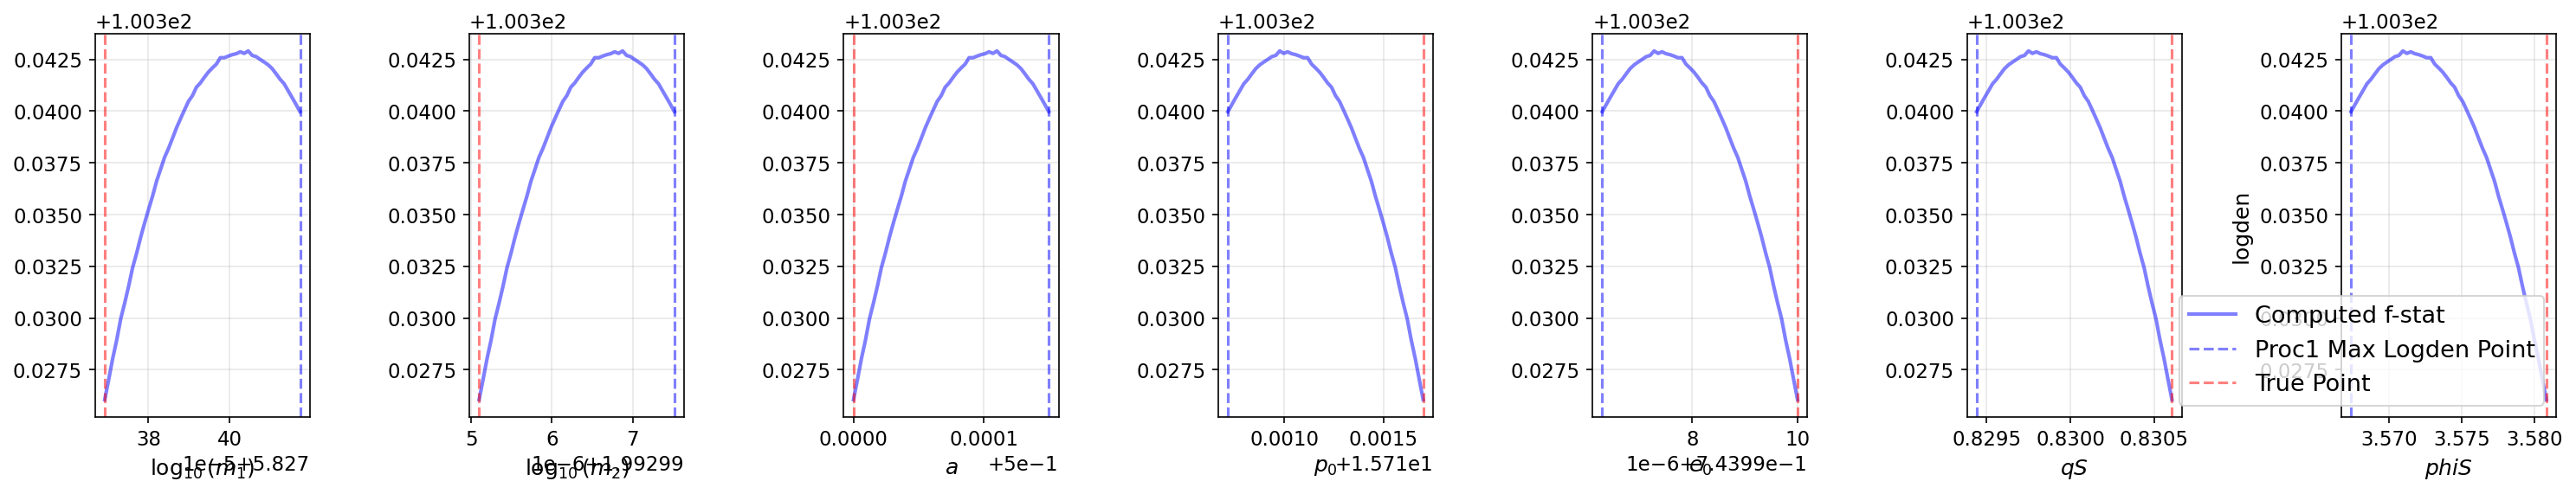

In [25]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [26]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [27]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [28]:
logden_tm = log_density(line_points_logm1.T)


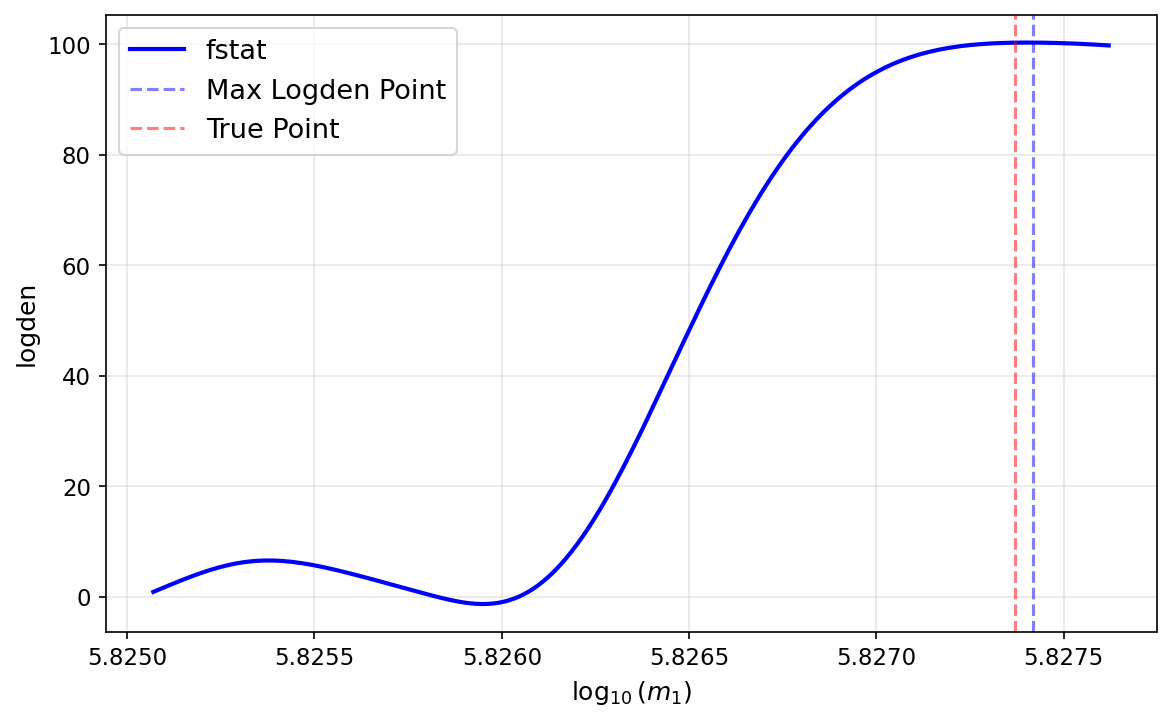

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='fstat')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

# alternate mode basis

In [30]:
n_vals = np.arange(-20, 20)
loglike_obj_alt = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

def log_density_alt(params):

    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cosqS_i)
            theta = [
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
            ]
            out[i] = float(loglike_obj_alt(theta))
        except Exception as e:
            print(e)
    return out

LogLike initialized.


In [31]:
log_density(maxld_pt1.reshape(1,-1))

array([100.33997373])

In [32]:
log_density_alt(maxld_pt1.reshape(1,-1))

array([98.91875359])